# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Credit Card Fraud Detection** dari Kaggle.
Dataset ini berisi transaksi kartu kredit yang dilakukan oleh pemegang kartu Eropa pada bulan September 2013.
Dataset ini bersifat **sangat imbalanced** karena hanya 0.172% transaksi yang merupakan fraud.

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:
1. **Sumber Dataset**: Kaggle - Credit Card Fraud Detection
2. **Karakteristik Dataset**: 
   - 284,807 transaksi
   - 31 fitur (Time, V1-V28, Amount, Class)
   - Fitur V1-V28 merupakan hasil PCA transformation
   - Class: 0 = Normal, 1 = Fraud

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

In [2]:
df = pd.read_csv('../namadataset_raw/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [3]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284777,172764.0,2.079137,-0.028723,-1.343392,0.358000,-0.045791,-1.345452,0.227476,-0.378355,0.665911,...,0.235758,0.829758,-0.002063,0.001344,0.262183,-0.105327,-0.022363,-0.060283,1.0,0.0
284778,172764.0,-0.764523,0.588379,-0.907599,-0.418847,0.901528,-0.760802,0.758545,0.414698,-0.730854,...,0.003530,-0.431876,0.141759,0.587119,-0.200998,0.267337,-0.152951,-0.065285,80.0,0.0
284779,172766.0,1.975178,-0.616244,-2.628295,-0.406246,2.327804,3.664740,-0.533297,0.842937,1.128798,...,0.086043,0.543613,-0.032129,0.768379,0.477688,-0.031833,0.014151,-0.066542,25.0,0.0
284780,172766.0,-1.727503,1.108356,2.219561,1.148583,-0.884199,0.793083,-0.527298,0.866429,0.853819,...,-0.094708,0.236818,-0.204280,1.158185,0.627801,-0.399981,0.510818,0.233265,30.0,0.0
284781,172766.0,-1.139015,-0.155510,1.894478,-1.138957,1.451777,0.093598,0.191353,0.092211,-0.062621,...,-0.191027,-0.631658,-0.147249,0.212931,0.354257,-0.241068,-0.161717,-0.149188,NaN,NaN


In [4]:
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\nNama kolom: {list(df.columns)}")

Jumlah baris: 284782
Jumlah kolom: 31

Nama kolom: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284782 entries, 0 to 284781
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284782 non-null  float64
 1   V1      284782 non-null  float64
 2   V2      284782 non-null  float64
 3   V3      284782 non-null  float64
 4   V4      284782 non-null  float64
 5   V5      284782 non-null  float64
 6   V6      284782 non-null  float64
 7   V7      284782 non-null  float64
 8   V8      284782 non-null  float64
 9   V9      284782 non-null  float64
 10  V10     284782 non-null  float64
 11  V11     284782 non-null  float64
 12  V12     284782 non-null  float64
 13  V13     284782 non-null  float64
 14  V14     284782 non-null  float64
 15  V15     284782 non-null  float64
 16  V16     284782 non-null  float64
 17  V17     284782 non-null  float64
 18  V18     284782 non-null  float64
 19  V19     284782 non-null  float64
 20  V20     284782 non-null  float64
 21  V21     28

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.
Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

## 4.1 Deskripsi Statistik

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284782.000000,284782.000000,284782.000000,284782.000000,284782.000000,284782.000000,284782.000000,284782.000000,284782.000000,284782.000000,...,284782.000000,284782.000000,284782.000000,284782.000000,284782.000000,284782.000000,284782.000000,284782.000000,284781.000000,284781.000000
mean,94807.015436,0.000096,-0.000115,0.000115,0.000030,-0.000048,-0.000040,0.000022,-0.000073,-0.000030,...,-0.000010,0.000002,-0.000015,-0.000007,0.000013,-0.000007,-0.000017,-0.000010,88.355200,0.001728
std,47484.611555,1.958483,1.651135,1.516072,1.415862,1.380180,1.332159,1.237076,1.194261,1.098615,...,0.734540,0.725693,0.624478,0.605653,0.521255,0.482233,0.403623,0.330084,250.130491,0.041529
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54201.000000,-0.920370,-0.598574,-0.890206,-0.848642,-0.691643,-0.768294,-0.554080,-0.208633,-0.643133,...,-0.228390,-0.542339,-0.161856,-0.354593,-0.317115,-0.326992,-0.070842,-0.052961,5.600000,0.000000
50%,84685.000000,0.018171,0.065453,0.179864,-0.019814,-0.054400,-0.274183,0.040097,0.022352,-0.051437,...,-0.029453,0.006778,-0.011208,0.040970,0.016627,-0.052158,0.001342,0.011243,22.000000,0.000000
75%,139311.750000,1.315648,0.803685,1.027220,0.743355,0.611828,0.398539,0.570447,0.327343,0.597140,...,0.186366,0.528530,0.147626,0.439525,0.350722,0.240946,0.091034,0.078276,77.190000,0.000000
max,172766.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


## 4.2 Cek Missing Values

In [7]:
missing_values = df.isnull().sum()
print("Missing Values per Kolom:")
print(missing_values)
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

Missing Values per Kolom:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    1
Class     1
dtype: int64

Total Missing Values: 2


## 4.3 Cek Data Duplikat

In [8]:
duplicates = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicates}")
print(f"Persentase duplikat: {duplicates / len(df) * 100:.2f}%")

Jumlah data duplikat: 1081
Persentase duplikat: 0.38%


## 4.4 Distribusi Kelas Target

In [9]:
class_dist = df['Class'].value_counts()
print("Distribusi Class:")
print(class_dist)
print(f"\nFraud Percentage: {class_dist[1] / len(df) * 100:.4f}%")
print(f"Normal Percentage: {class_dist[0] / len(df) * 100:.4f}%")

Distribusi Class:
Class
0.0    284289
1.0       492
Name: count, dtype: int64

Fraud Percentage: 0.1728%
Normal Percentage: 99.8269%


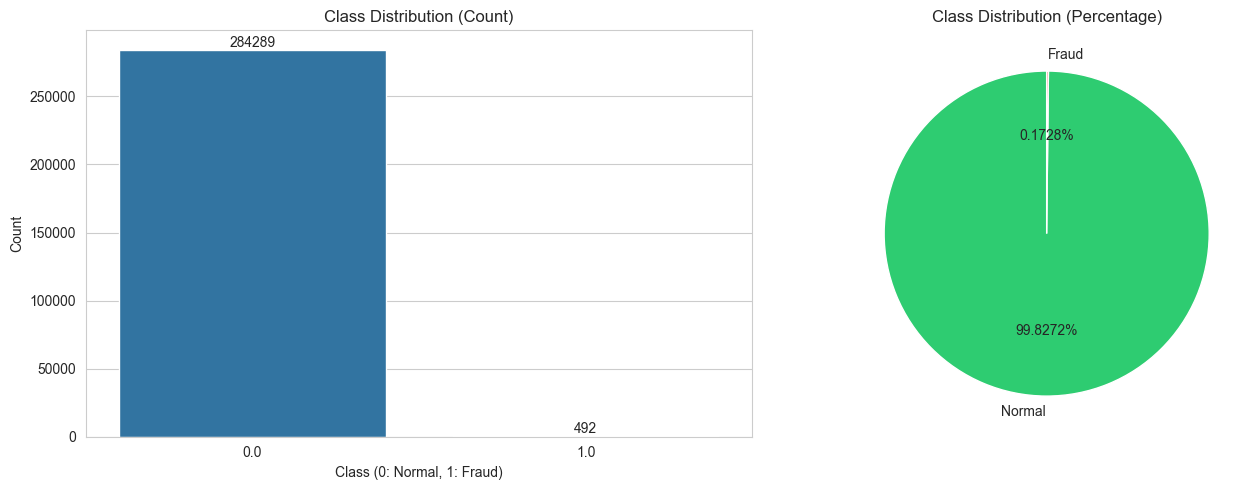

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Class', data=df, ax=axes[0])
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('Class (0: Normal, 1: Fraud)')
axes[0].set_ylabel('Count')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom')

class_pct = df['Class'].value_counts(normalize=True) * 100
axes[1].pie(class_pct, labels=['Normal', 'Fraud'], autopct='%1.4f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Class Distribution (Percentage)')

plt.tight_layout()
plt.savefig('namadataset_preprocessing/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 Distribusi Fitur Amount

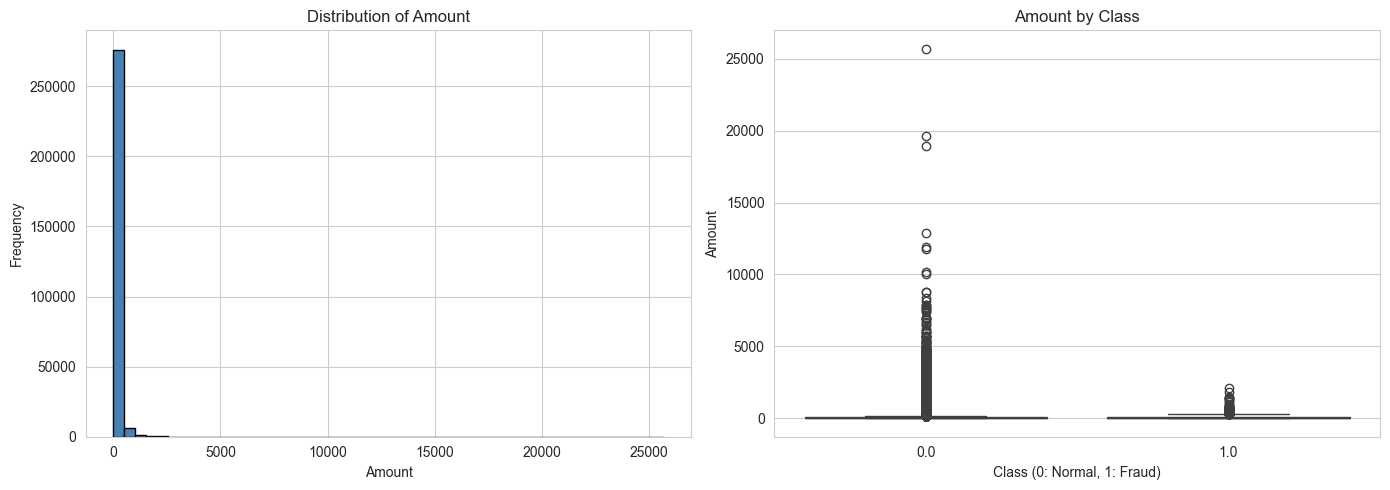

Amount - Mean: 88.36, Std: 250.13
Amount - Min: 0.00, Max: 25691.16


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Amount'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Amount')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

sns.boxplot(x='Class', y='Amount', data=df, ax=axes[1])
axes[1].set_title('Amount by Class')
axes[1].set_xlabel('Class (0: Normal, 1: Fraud)')
axes[1].set_ylabel('Amount')

plt.tight_layout()
plt.savefig('namadataset_preprocessing/eda_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Amount - Mean: {df['Amount'].mean():.2f}, Std: {df['Amount'].std():.2f}")
print(f"Amount - Min: {df['Amount'].min():.2f}, Max: {df['Amount'].max():.2f}")

## 4.6 Distribusi Fitur Time

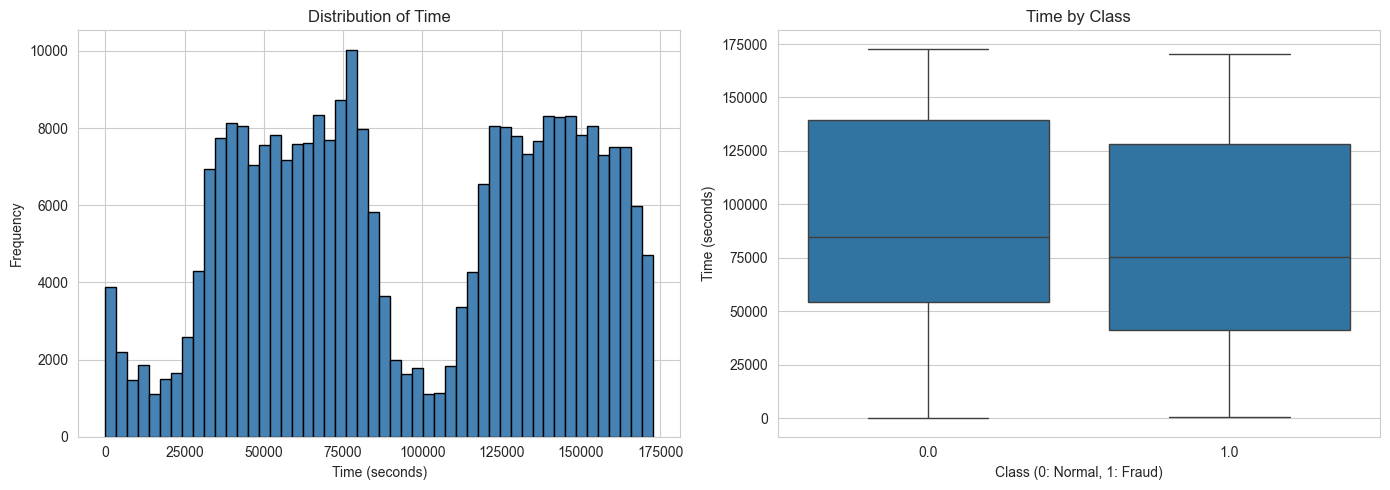

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Time'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Time')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Frequency')

sns.boxplot(x='Class', y='Time', data=df, ax=axes[1])
axes[1].set_title('Time by Class')
axes[1].set_xlabel('Class (0: Normal, 1: Fraud)')
axes[1].set_ylabel('Time (seconds)')

plt.tight_layout()
plt.savefig('namadataset_preprocessing/eda_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.7 Distribusi Fitur V1-V28

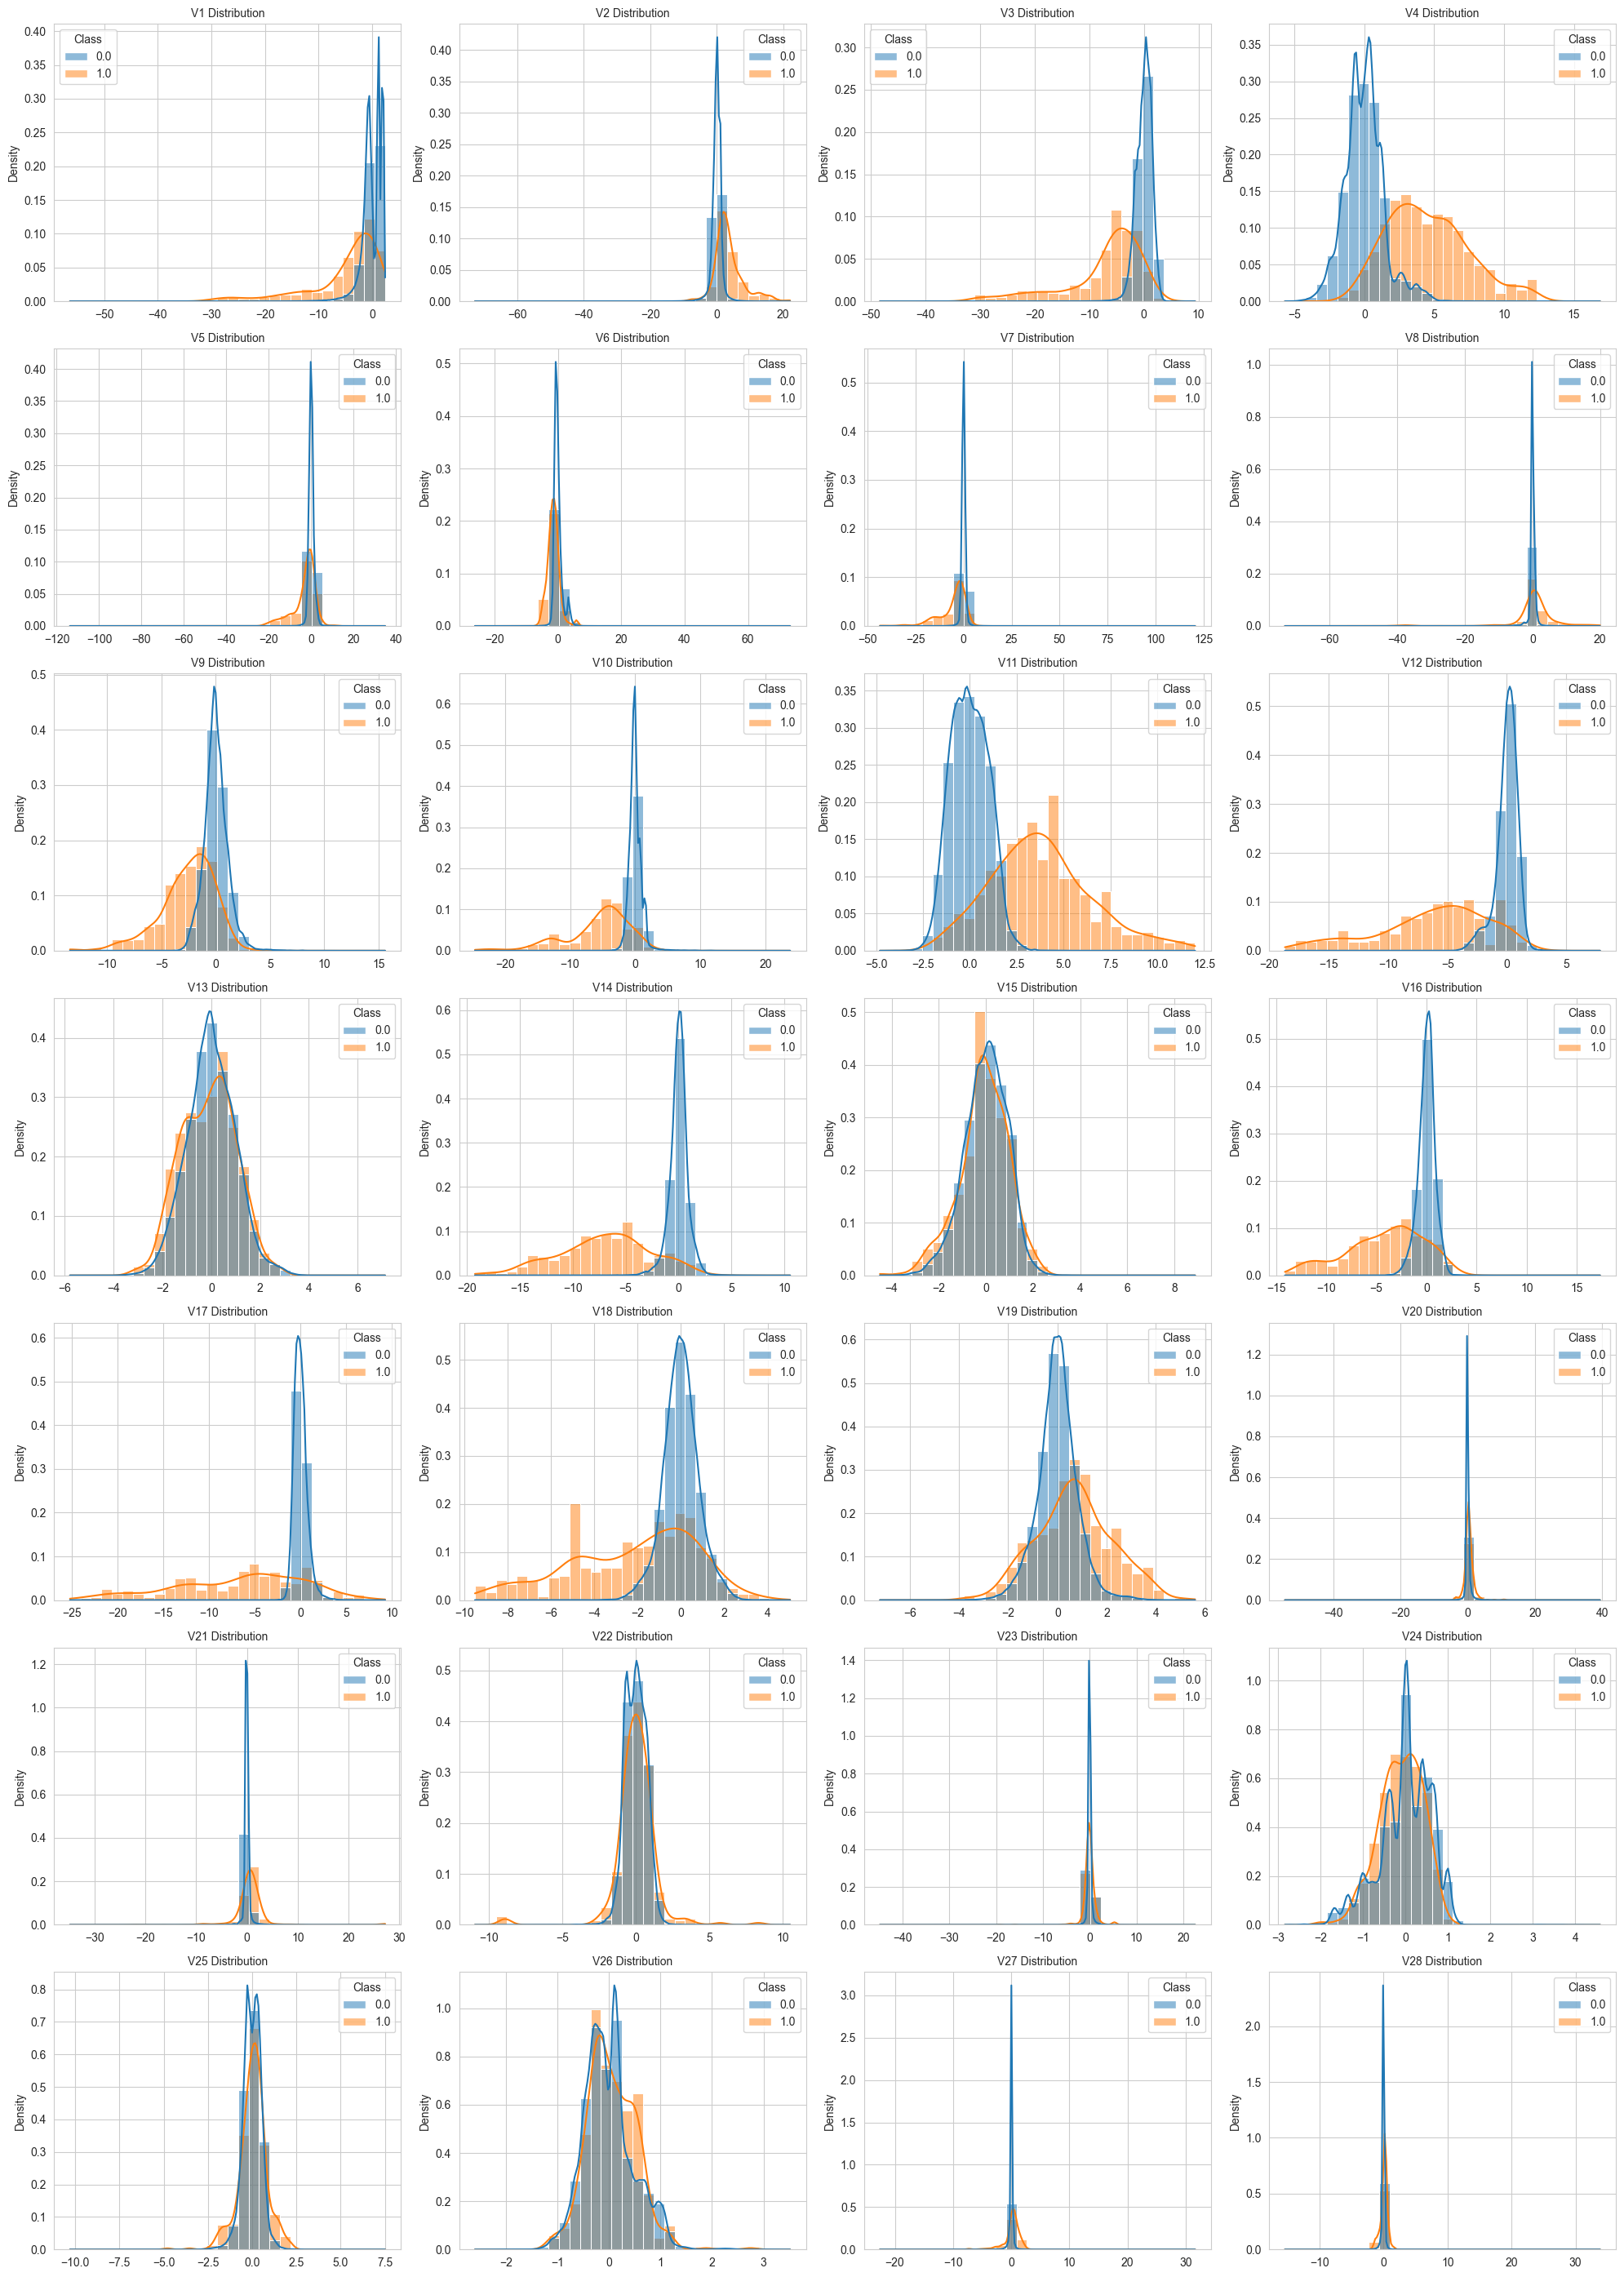

In [13]:
v_cols = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, col in enumerate(v_cols):
    sns.histplot(data=df, x=col, hue='Class', bins=30, ax=axes[i],
                 kde=True, stat='density', common_norm=False)
    axes[i].set_title(f'{col} Distribution', fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('namadataset_preprocessing/eda_v_features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.8 Korelasi Fitur

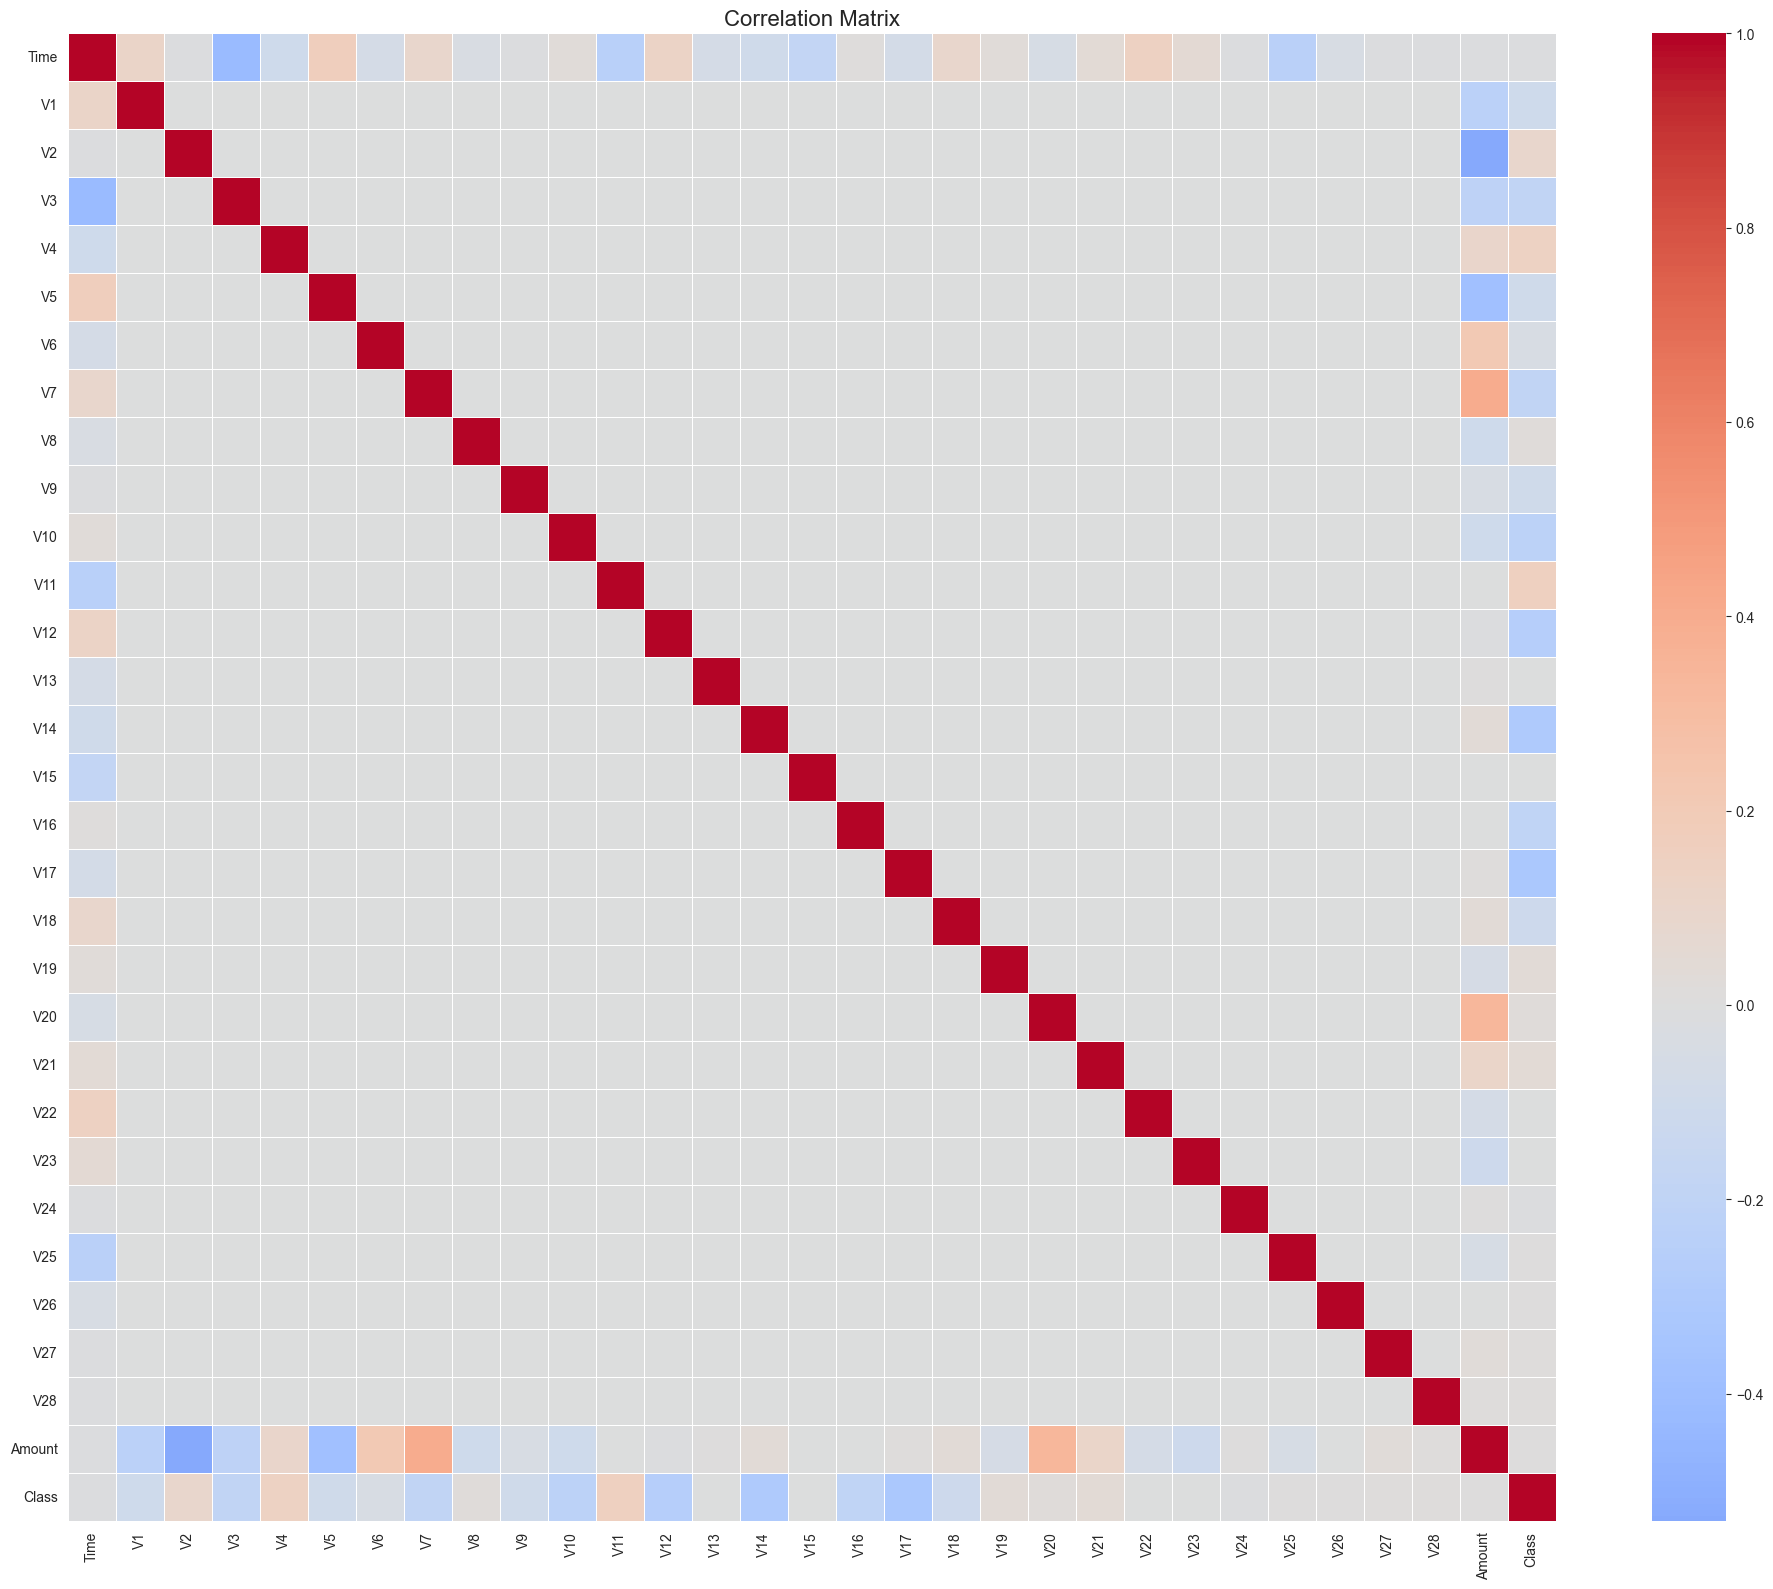

In [14]:
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('namadataset_preprocessing/eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Korelasi fitur dengan Class:
V11       0.154880
V4        0.133453
V2        0.091305
V21       0.040415
V19       0.034786
V20       0.020092
V8        0.019880
V27       0.017583
V28       0.009538
Amount    0.005631
V26       0.004456
V25       0.003307
V22       0.000805
V23      -0.002684
V15      -0.004223
V13      -0.004571
V24      -0.007221
Time     -0.012318
V6       -0.043648
V5       -0.094982
V9       -0.097737
V1       -0.101365
V18      -0.111488
V7       -0.187268
V3       -0.192996
V16      -0.196544
V10      -0.216916
V12      -0.260602
V14      -0.302563
V17      -0.326492
Name: Class, dtype: float64


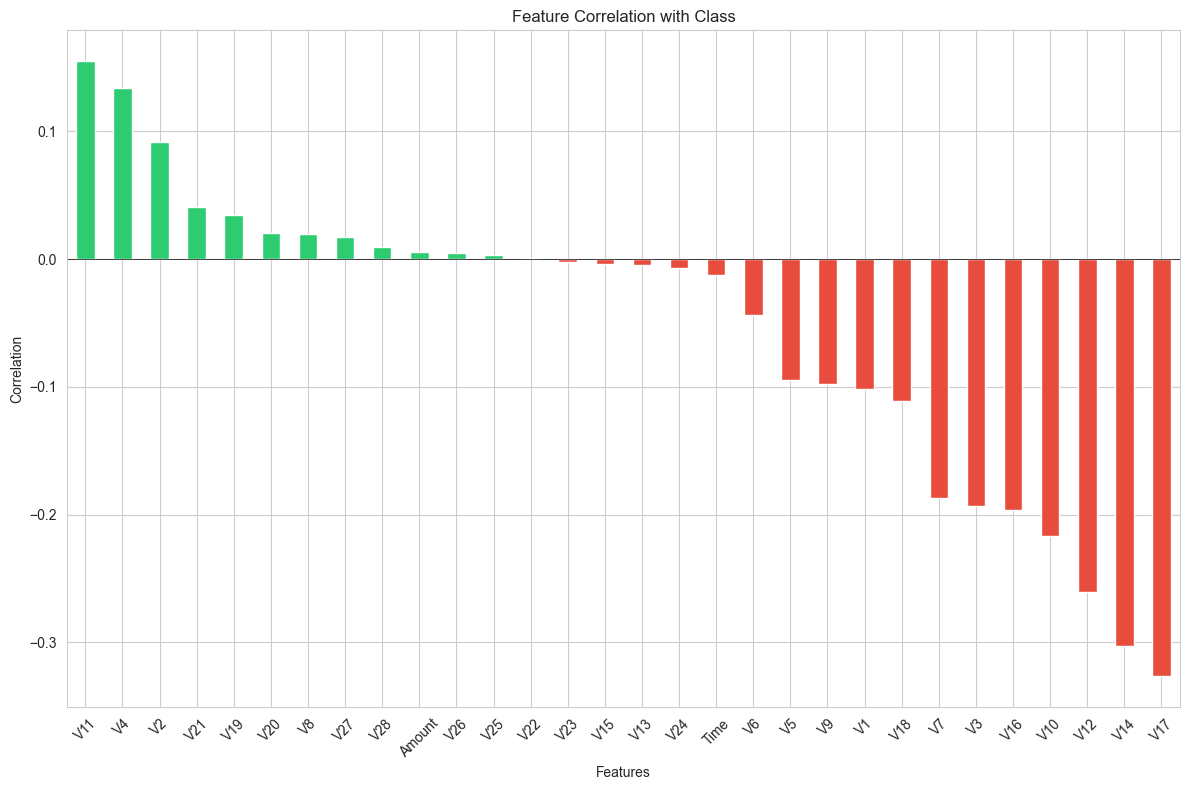

In [15]:
corr_with_class = df.corr()['Class'].drop('Class').sort_values(ascending=False)
print("Korelasi fitur dengan Class:")
print(corr_with_class)

fig, ax = plt.subplots(figsize=(12, 8))
corr_with_class.plot(kind='bar', ax=ax, color=['#e74c3c' if x < 0 else '#2ecc71' for x in corr_with_class])
ax.set_title('Feature Correlation with Class')
ax.set_xlabel('Features')
ax.set_ylabel('Correlation')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('namadataset_preprocessing/eda_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.9 Analisis Outlier

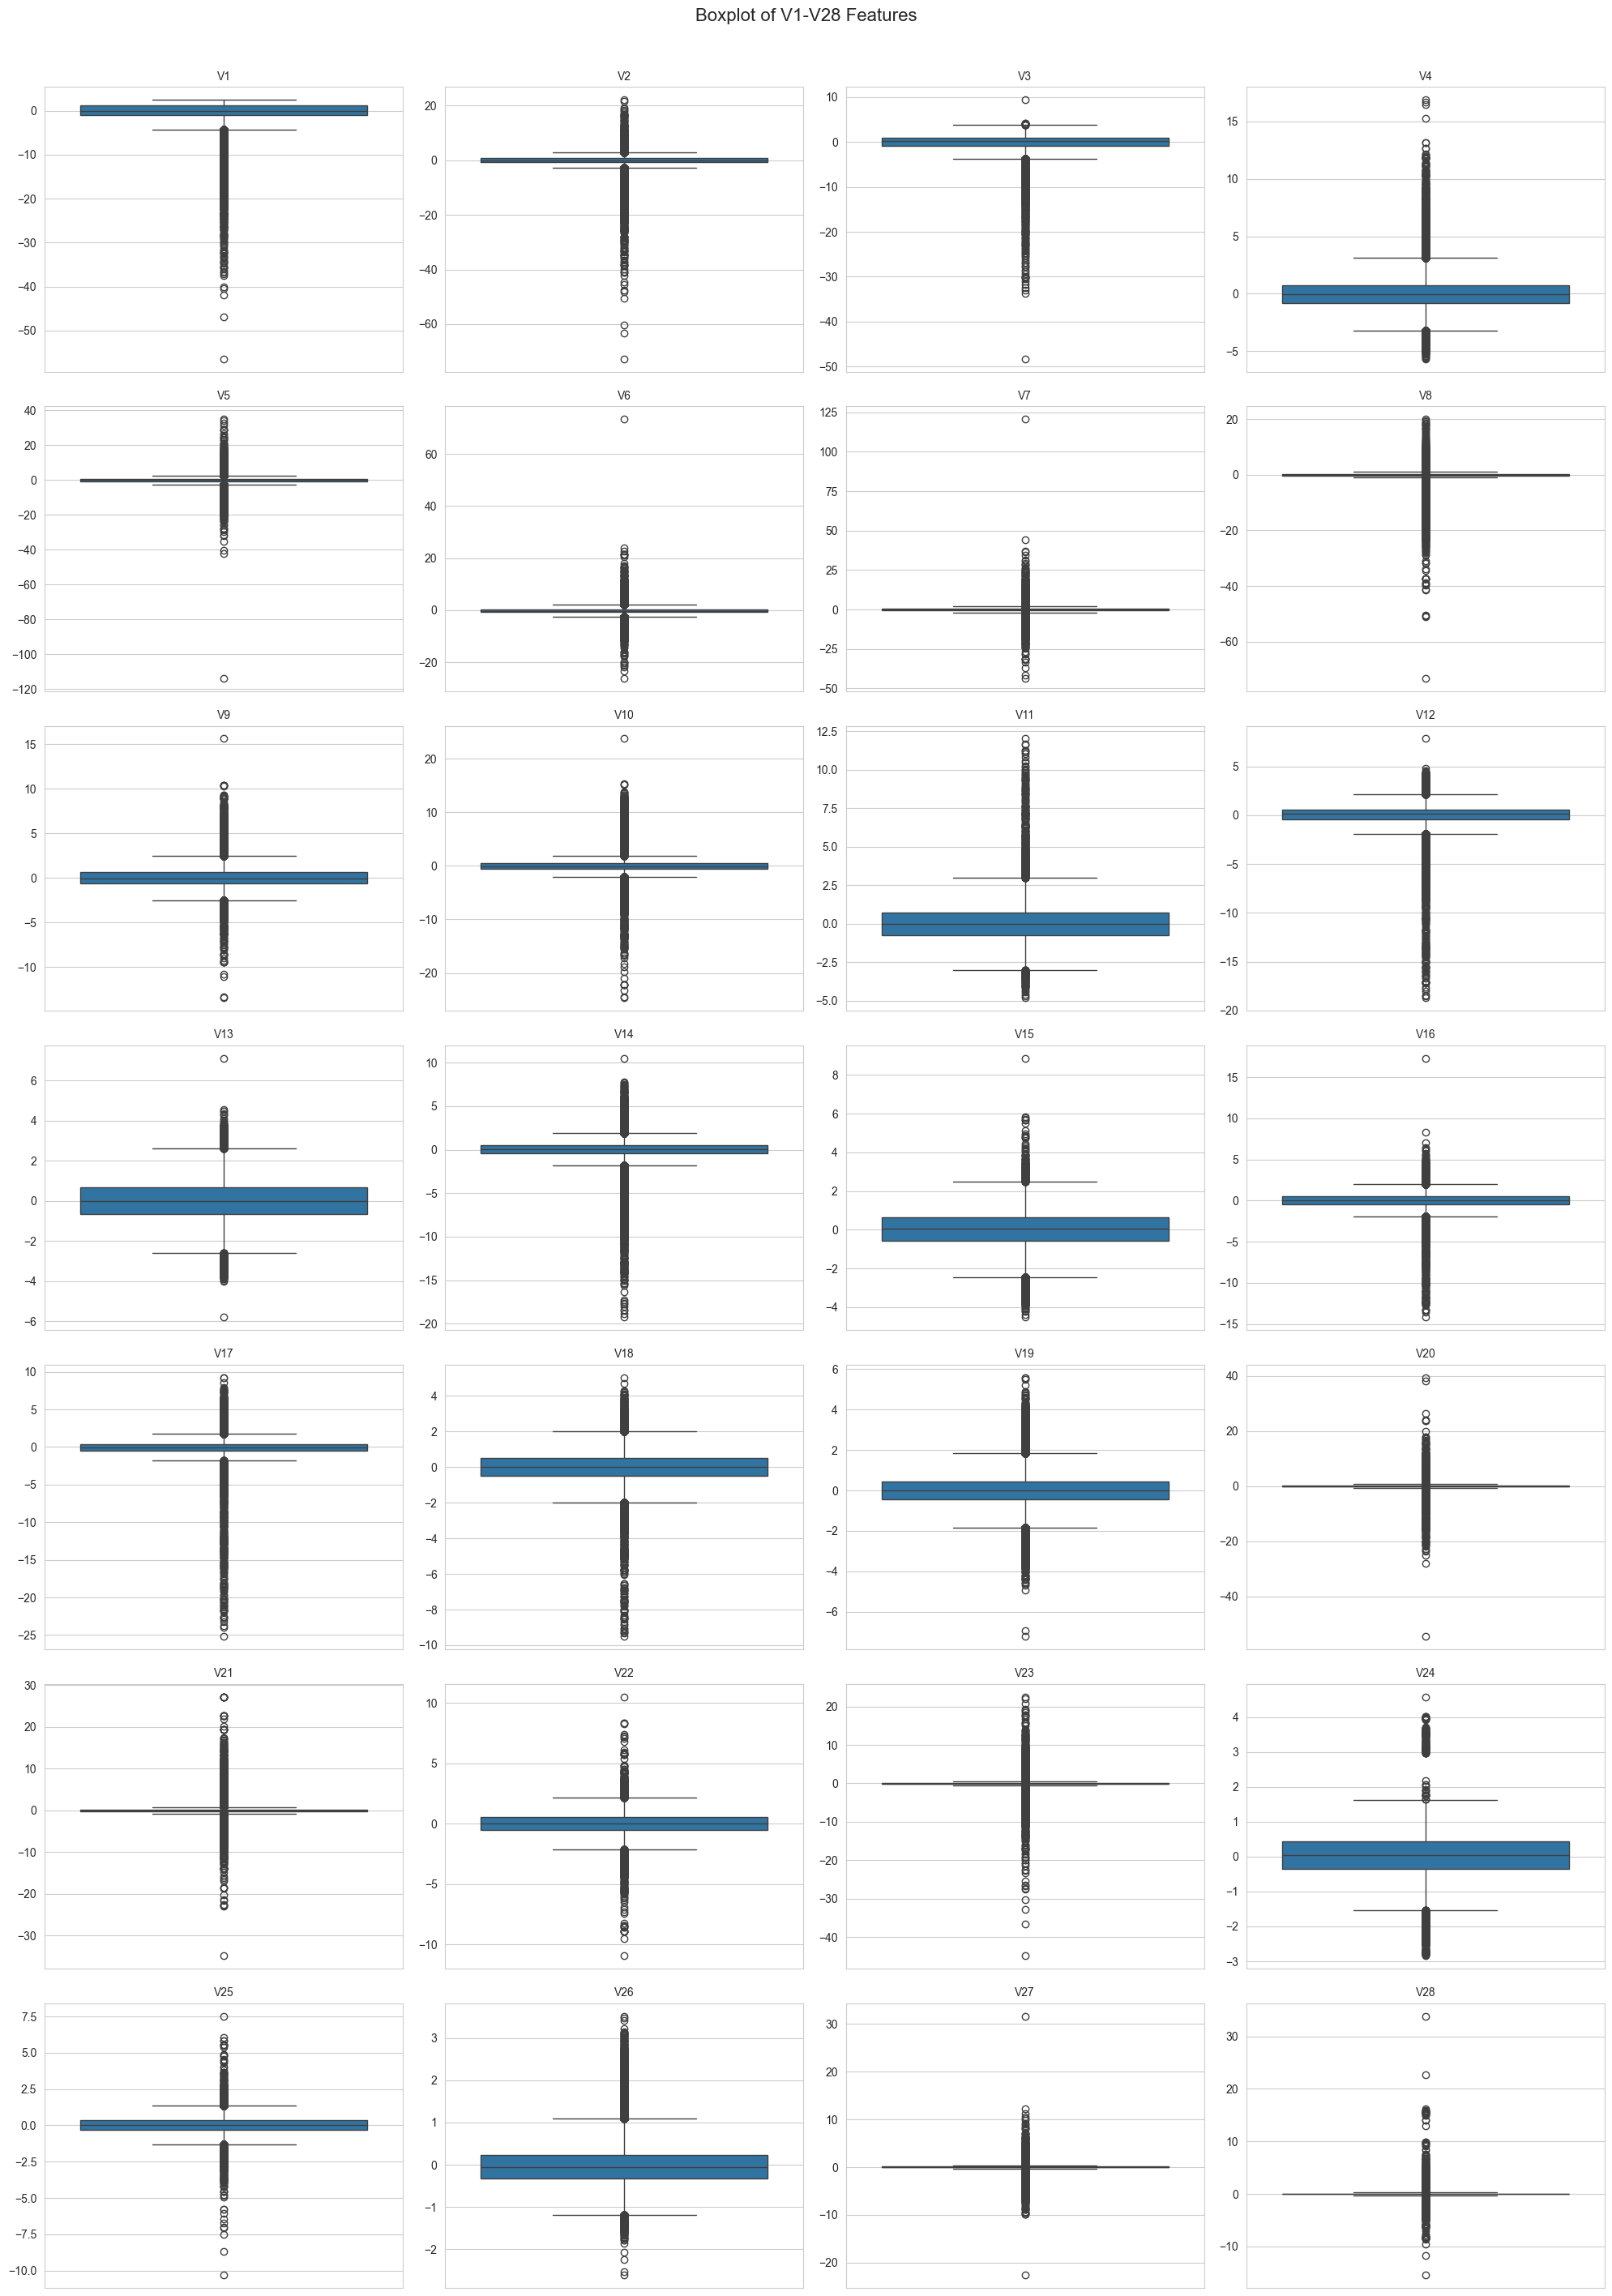

In [16]:
fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, col in enumerate(v_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.suptitle('Boxplot of V1-V28 Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('namadataset_preprocessing/eda_outlier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.10 Ringkasan EDA

Berdasarkan EDA yang telah dilakukan, berikut adalah temuan utama:

1. **Missing Values**: Tidak terdapat missing values dalam dataset
2. **Data Duplikat**: Terdapat data duplikat yang perlu dihapus
3. **Class Imbalance**: Dataset sangat imbalanced (0.17% fraud)
4. **Distribusi Fitur**: Fitur V1-V28 sudah di-scale (hasil PCA), namun Time dan Amount belum
5. **Korelasi**: Beberapa fitur memiliki korelasi moderat dengan Class
6. **Outlier**: Terdapat outlier pada beberapa fitur V, namun karena ini data transaksi fraud, outlier bisa jadi penting

Langkah preprocessing yang diperlukan:
- Hapus data duplikat
- Standarisasi fitur Time dan Amount
- Split data menjadi train dan test set dengan stratifikasi

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Berikut adalah tahapan-tahapan yang dilakukan:
1. Menghapus Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Train-Test Split

## 5.1 Menghapus Missing Values

In [17]:
print(f"Jumlah baris sebelum hapus missing values: {len(df)}")
df = df.dropna()
print(f"Jumlah baris setelah hapus missing values: {len(df)}")

Jumlah baris sebelum hapus missing values: 284782
Jumlah baris setelah hapus missing values: 284781


## 5.2 Menghapus Data Duplikat

In [18]:
print(f"Jumlah baris sebelum hapus duplikat: {len(df)}")
df = df.drop_duplicates()
print(f"Jumlah baris setelah hapus duplikat: {len(df)}")

Jumlah baris sebelum hapus duplikat: 284781
Jumlah baris setelah hapus duplikat: 283700


## 5.3 Standarisasi Fitur Time dan Amount

In [19]:
scaler = StandardScaler()
df['Scaled_Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df['Scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)

print("Kolom setelah standarisasi:")
print(df.columns.tolist())
df.head()

Kolom setelah standarisasi:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Scaled_Time', 'Scaled_Amount']


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Scaled_Time,Scaled_Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.0,-1.996828,0.244167
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0.0,-1.996828,-0.342592
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0.0,-1.996807,1.158829
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.0,-1.996807,0.139858
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.0,-1.996786,-0.073832


## 5.4 Train-Test Split

In [20]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape Training Data: {X_train.shape}")
print(f"Shape Testing Data: {X_test.shape}")
print(f"\nTraining - Normal: {(y_train == 0).sum()}, Fraud: {(y_train == 1).sum()}")
print(f"Testing - Normal: {(y_test == 0).sum()}, Fraud: {(y_test == 1).sum()}")

Shape Training Data: (226960, 30)
Shape Testing Data: (56740, 30)

Training - Normal: 226582, Fraud: 378
Testing - Normal: 56645, Fraud: 95


## 5.5 Simpan Data Preprocessing

In [21]:
train_df = X_train.copy()
train_df['Class'] = y_train.values
train_df.to_csv('namadataset_preprocessing/creditcard_train_preprocessed.csv', index=False)

test_df = X_test.copy()
test_df['Class'] = y_test.values
test_df.to_csv('namadataset_preprocessing/creditcard_test_preprocessed.csv', index=False)

full_df = pd.concat([X_train, X_test], axis=0)
full_df['Class'] = pd.concat([y_train, y_test], axis=0)
full_df.to_csv('namadataset_preprocessing/creditcard_preprocessed.csv', index=False)

print("Data preprocessed berhasil disimpan!")
print(f"  - creditcard_train_preprocessed.csv ({len(train_df)} rows)")
print(f"  - creditcard_test_preprocessed.csv ({len(test_df)} rows)")
print(f"  - creditcard_preprocessed.csv ({len(full_df)} rows)")

Data preprocessed berhasil disimpan!
  - creditcard_train_preprocessed.csv (226960 rows)
  - creditcard_test_preprocessed.csv (56740 rows)
  - creditcard_preprocessed.csv (283700 rows)
